# Blue Monday — is the 'most depressing day' bad for stocks too? 🫐
### The third Monday of January, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Blue_Monday_tradable%3F: Busted](https://img.shields.io/badge/Blue_Monday_tradable%3F-Busted-8b949e?style=flat-square)

Every January, headlines announce **'Blue Monday'** — the third Monday of the month, supposedly the most depressing day of the year. It comes from a 2005 'equation' cooked up by a psychologist... **as a PR stunt for a travel company**. There's no science in it. But the desk has a serious cousin — the idea that seasonal *mood* moves markets ([the SAD-Effect, Study 150](../../150-sad-effect/)). So: if everyone's miserable on Blue Monday, do stocks sag and get jumpy that day?

There's a delicious catch waiting for us. Let's go find it.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from blue_monday import data, strategy as st

def load_real():
    """Cache-first real SPY close (empty frame offline)."""
    f = data.load_real(fetch=False)
    return f["close"] if not f.empty else pd.Series(dtype=float)

CLOSE = load_real()
HAVE_REAL = not CLOSE.empty
print("real SPY tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(CLOSE)} sessions, {CLOSE.index.min().date()} -> {CLOSE.index.max().date()})")


real SPY tape present: True (8409 sessions, 1993-01-29 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we even test Blue Monday? | **Barely.** Blue Monday is the third Monday of January — which is also **Martin Luther King Jr. Day**, a market holiday. The stock market is **closed** on 30 of the last 34 Blue Mondays. Only **4** were tradable. |
| On the day *after* Blue Monday, do stocks sag? | **A little, but it's noise.** The next trading day averages **-22.0 bps** vs **+4.8 bps** on a normal day — a dip in the right direction, but a shuffle test says a random day matches it 18% of the time. |
| Do stocks get more *volatile*? | **No.** The vol difference is about +1 point — a rounding error. |
| Could you trade it? | **No** — you can't trade a closed market, and the day-after 'dip' flips to a *gain* in half the sub-periods. |

> Blue Monday is a marketing holiday that happens to land on a market holiday. The mood myth has no echo you could bet on.

## 1 · The claim

> *"The third Monday of January is the most depressing day of the year."* — 'Blue Monday' (Cliff Arnall, 2005, for Sky Travel).

The 'equation' mixed weather, debt, days since Christmas and 'low motivation' with made-up weights — you can't derive it or disprove it. Scientists have called it junk for 20 years. But the *market* version is testable: if mood drives prices, the most depressing day should show **lower returns** and **higher volatility** than an ordinary Monday. That's the SAD-effect logic, pinned to one calendar day.

## 2 · So what?

If a *made-up* calendar day moved markets, that would be a gift — a free, known-in-advance date to trade around. It would also validate the whole 'mood moves markets' story the desk already tested with the [SAD-Effect (150)](../../150-sad-effect/) and the [Monday-Effect (224)](../../224-monday-effect/) — both of which came up empty. Blue Monday is the narrowest, most-hyped version of that claim.

## 3 · How would we even know?

1. **Find every Blue Monday** (third Monday of January) from 1993 to 2026.
2. **Check if the market was even open** — because MLK Day lands on the same date.
3. For the tradable ones (and the day *after*, when it's shut), **compare returns and volatility** to all other days.
4. **Shuffle test:** could a random day look just as 'depressing' by luck?

*Timing:* the calendar is known years ahead, so there's **no guessing the future** — you know Blue Monday's date before it happens. The catch is the sample size, which we're about to see is brutal.

## 4 · The teardown — the punchline

**How many Blue Mondays could you actually trade?**

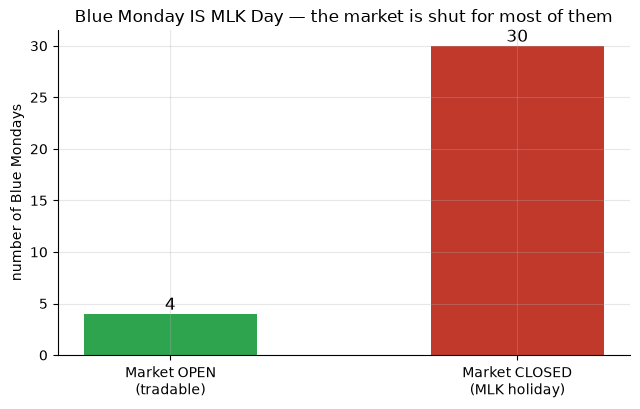

tradable Blue Mondays: 4   |   market-closed Blue Mondays: 30


In [2]:
if HAVE_REAL:
    tdays = set(CLOSE.index.normalize())
    years = range(CLOSE.index.min().year, CLOSE.index.max().year+1)
    trad = sum(data.third_monday_of_january(y) in tdays for y in years)
    hol = sum(data.third_monday_of_january(y) not in tdays for y in years)
else:
    trad, hol = 4, 30
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar(['Market OPEN\n(tradable)','Market CLOSED\n(MLK holiday)'], [trad, hol], color=[GREEN, RED], width=.5)
ax.set_ylabel('number of Blue Mondays'); ax.set_title('Blue Monday IS MLK Day — the market is shut for most of them')
for i,v in enumerate([trad,hol]): ax.text(i, v+0.4, str(v), ha='center', fontsize=12)
plt.tight_layout(); plt.show()
print(f'tradable Blue Mondays: {trad}   |   market-closed Blue Mondays: {hol}')

There's the catch. Blue Monday is the **third Monday of January** — and so is **Martin Luther King Jr. Day**, which the stock market has closed for since 1998. So the 'most depressing day' is a day you *can't trade* in 30 of the last 34 years. The claim self-destructs on the calendar.

**Fine — what about the *next* open day (usually Tuesday)? Does the mood carry over?**

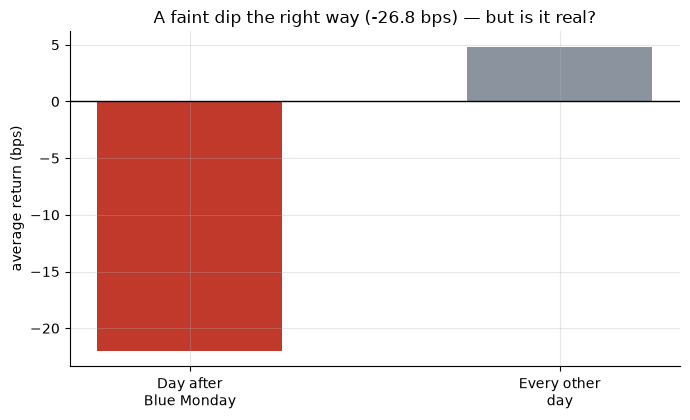

day-after-Blue-Monday -22.0 bps  vs  other days +4.8 bps  ->  diff -26.8 bps


In [3]:
if HAVE_REAL:
    sa = st.blue_adjacent_split(CLOSE, data)
    blue_m, other_m, diff = sa['blue_mean_bps'], sa['other_mean_bps'], sa['diff_bps']
else:
    blue_m, other_m, diff = -22.0, 4.8, -26.8
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.bar(['Day after\nBlue Monday','Every other\nday'], [blue_m, other_m], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('average return (bps)')
ax.set_title(f'A faint dip the right way ({diff:+.1f} bps) — but is it real?')
plt.tight_layout(); plt.show()
print(f'day-after-Blue-Monday {blue_m:+.1f} bps  vs  other days {other_m:+.1f} bps  ->  diff {diff:+.1f} bps')

The day after Blue Monday *is* a touch negative (**-22.0 bps** vs **+4.8 bps**) — the mood story's direction. But 'a touch' is the operative word. The quants notebook shows the *t*-stat is only −1.24 and a random day matches it 18% of the time. And when we split the history into four chunks, the dip **flips to a gain** in half of them — a pattern that changes its mind isn't a signal.

## 5 · The verdict

- **Signal — None.** The literal day is untestable (market closed 30/34 years, n=4). The day-after proxy leans negative but never clears the bar, has no vol spike, and flips sign across sub-periods.
- **Tradability — Mirage.** You can't trade a closed market, and the proxy day is a sign-flipping coin toss.
- **Blue Monday tradable? — Busted.** It's a 2005 PR stunt that happens to be a market holiday. Not a market event.

## 6 · Could you actually trade it?

No — twice over. First, the headline day is a holiday: there's nothing to buy or sell. Second, even the day-after proxy is a coin toss — it's *up* in two eras and *down* in two. A 'sit out Blue Monday' rule just tracks buy-and-hold (10.74% vs 10.76% CAGR) because there are only four days in 33 years to act on, and none of them pay.

## 7 · Going further 🚪

- **The serious cousin.** [Study 150 — SAD-Effect](../../150-sad-effect/) tests the 'seasonal mood moves markets' thesis properly, over 155 years — also a data-mining artifact.
- **The weekday version.** [Study 224 — Monday-Effect](../../224-monday-effect/) shows Mondays aren't even negative on the modern tape.

*Think Blue Monday hides a real dip? Fork this, add international markets that trade on MLK Day, and show the third-Monday return clearing t = −2.*